# 一、项目背景

对淘宝用户行为数据进行分析，发掘三个层面的关键业务问题，用户层面，商品层面，场景层面，针对不同层面的问题，探究提升GMV（商品交易总额）的方法。

# 二、数据来源与理解

本项目使用的数据来自阿里云天池平台的“淘宝用户购物行为数据集” (User Behavior Data from Taobao for Recommendation)。
该数据集由阿里巴巴提供，遵循 CC BY-NC-SA 4.0 许可协议。
本项目仅用于非商业学习和研究目的。基于此数据产生的衍生作品同样遵循该许可协议。
数据来源链接：https://tianchi.aliyun.com/dataset/649

本数据集包含了2017年11月25日至2017年12月3日之间，有行为的约一百万随机用户的所有行为

共计5列字段，分别是：userid（用户ID）、itemid（商品ID）、categoryid（商品类目ID）、type（行为类型）和timestamp（时间戳）。

用户行为类型共有四种，分别是：pv、buy、cart和fav。

数据集大小：用户数量987994，商品数量4162024，用户数量987994，商品类目数量9439，所有行为数量100150807。

## 三、导入基本库和读取数据

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
columns = ['user_id','item_id','category_id','behavior','timestamp']
data = pd.read_csv('E:/Taobao/data/UserBehavior.csv',encoding = 'utf-8',names = columns,chunksize = 5000000,header=None,iterator = True)
# 设置中文字体和图表样式
# 确保中文显示正常
plt.rcParams['font.sans-serif'] = ['SimHei', 'WenQuanYi Micro Hei', 'Heiti TC', 'sans-serif']
plt.rcParams['axes.unicode_minus'] = False
sns.set_style("whitegrid")
columns = ['user_id','item_id','category_id','behavior','timestamp']
df = data.get_chunk(5000000)

## 四、数据基本信息

In [12]:
df.sample(10)

,user_id,item_id,category_id,behavior,timestamp
1282763,141484,3864239,475867,pv,1512181721
4899555,305265,1145208,2043591,pv,1511920792
3111690,223264,2614438,4170419,pv,1511965683
1838918,167103,3574721,4801426,pv,1511602803
1165076,135992,3096591,4095810,cart,1512136527
4531811,288019,2303412,1349634,pv,1512051450
3552194,243076,383513,3738615,pv,1511792956
1047139,130706,3148174,4357323,pv,1511880496
3768381,252769,4712506,1080785,pv,1512150739
711238,115651,42876,1573465,pv,1511620759


In [13]:
print("\n=== 数据信息摘要 ===")
print(df.info())
print("\n=== 基本统计信息 ===")
print(df.describe())
print("\n=== 唯一值统计 ===")
print(df.nunique())


=== 数据信息摘要 ===
<class 'pandas.DataFrame'>
RangeIndex: 5000000 entries, 0 to 4999999
Data columns (total 5 columns):
 #   Column       Dtype
---  ------       -----
 0   user_id      int64
 1   item_id      int64
 2   category_id  int64
 3   behavior     str  
 4   timestamp    int64
dtypes: int64(4), str(1)
memory usage: 190.7 MB
None

=== 基本统计信息 ===
            user_id       item_id   category_id     timestamp
count  5.000000e+06  5.000000e+06  5.000000e+06  5.000000e+06
mean   2.446809e+05  2.579267e+06  2.710101e+06  1.511963e+09
std    2.265588e+05  1.488103e+06  1.464218e+06  8.400232e+05
min    1.000000e+00  3.000000e+00  2.171000e+03  4.401600e+04
25%    1.388410e+05  1.294875e+06  1.349561e+06  1.511763e+09
50%    2.010450e+05  2.578621e+06  2.710853e+06  1.511966e+09
75%    2.637270e+05  3.862411e+06  4.145813e+06  1.512181e+09
max    1.018011e+06  5.163067e+06  5.161669e+06  2.122867e+09

=== 唯一值统计 ===
user_id          48984
item_id        1080623
category_id       7354
beha

# 五、数据清洗


## 1.缺失值检查

In [14]:
missing_values = df.isnull().sum()
print('缺失值统计：',missing_values)
missing_percentage = (missing_values/len(df))*100
print('缺失值占比：',missing_percentage,'%')

缺失值统计： user_id        0
item_id        0
category_id    0
behavior       0
timestamp      0
dtype: int64
缺失值占比： user_id        0.0
item_id        0.0
category_id    0.0
behavior       0.0
timestamp      0.0
dtype: float64 %


## 2. 重复值检查

In [15]:
duplicate_values = df.duplicated().sum()
print('重复值统计：',duplicate_values)
duplicate_percentage = (duplicate_values/len(df))*100
print('重复值占比：',duplicate_percentage,'%')

重复值统计： 5
重复值占比： 9.999999999999999e-05 %


## 3.将时间戳转换为datetime格式

In [16]:
from datetime import datetime,timedelta
df['time'] = pd.to_datetime(df['timestamp'], unit='s') + timedelta(hours=8)


In [17]:
#剔除不在日期范围（2017年11月25日至2017年12月3日之间）内的数据
df = df[(df['time'].between('2017-11-25 00:00:00','2017-12-03 23:59:59'))]
df.drop(columns = ['timestamp'], inplace = True)


In [18]:
df['date'] = df['time'].dt.date
df['hour'] = df['time'].dt.hour
df['weekday'] = df['time'].dt.weekday
df['is_weekend'] = df['weekday'].isin([5, 6]).astype(int)

In [19]:
df.head()

,user_id,item_id,category_id,behavior,time,date,hour,weekday,is_weekend
0,1,2268318,2520377,pv,2017-11-25 01:21:10,2017-11-25,1,5,1
1,1,2333346,2520771,pv,2017-11-25 06:15:33,2017-11-25,6,5,1
2,1,2576651,149192,pv,2017-11-25 09:21:25,2017-11-25,9,5,1
3,1,3830808,4181361,pv,2017-11-25 15:04:53,2017-11-25,15,5,1
4,1,4365585,2520377,pv,2017-11-25 15:49:06,2017-11-25,15,5,1


## 4.检查异常行为

In [20]:
behavior_counts = df['behavior'].value_counts()
print(behavior_counts)
print(df.nunique())

behavior
pv      4472600
cart     279512
fav      145125
buy      100131
Name: count, dtype: int64
user_id          48984
item_id        1080286
category_id       7352
behavior             4
time            717243
date                 9
hour                24
weekday              7
is_weekend           2
dtype: int64


In [21]:
df.info()

<class 'pandas.DataFrame'>
Index: 4997368 entries, 0 to 4999999
Data columns (total 9 columns):
 #   Column       Dtype         
---  ------       -----         
 0   user_id      int64         
 1   item_id      int64         
 2   category_id  int64         
 3   behavior     str           
 4   time         datetime64[us]
 5   date         object        
 6   hour         int32         
 7   weekday      int32         
 8   is_weekend   int64         
dtypes: datetime64[us](1), int32(2), int64(4), object(1), str(1)
memory usage: 343.1+ MB


本次用于数据分析的数据为:

用户数量：48984

商品数量：1080286

商品类目数量：7352

用户行为数量：4997368

# 六、数据分析和可视化

## 1.用户层面


### (1).用户每日行为

In [22]:
#buy
daily_buy = df[df['behavior'] == 'buy'].groupby('date').size()
#pv
daily_pv = df[df['behavior'] == 'pv'].groupby('date').size()
#cart
daily_cart = df[df['behavior'] == 'cart'].groupby('date').size()
#fav
daily_fav = df[df['behavior'] == 'fav'].groupby('date').size()


In [23]:
# 计算每日行为占比
# 合并每日各行为数据
behavior_daily = pd.DataFrame({
    'pv': daily_pv,
    'cart': daily_cart,
    'fav': daily_fav,
    'buy': daily_buy
}).fillna(0)

# 计算每日总行为数
behavior_daily['total'] = behavior_daily.sum(axis=1)

# 计算每日各行为占比（保留两位小数）
behavior_daily['浏览占比(%)'] = (behavior_daily['pv'] / behavior_daily['total'] * 100).round(2)
behavior_daily['购物车占比(%)'] = (behavior_daily['cart'] / behavior_daily['total'] * 100).round(2)
behavior_daily['收藏占比(%)'] = (behavior_daily['fav'] / behavior_daily['total'] * 100).round(2)
behavior_daily['购买占比(%)'] = (behavior_daily['buy'] / behavior_daily['total'] * 100).round(2)

# 只保留占比列
daily_behavior = behavior_daily[['浏览占比(%)', '购物车占比(%)', '收藏占比(%)', '购买占比(%)']]
daily_behavior


,浏览占比(%),购物车占比(%),收藏占比(%),购买占比(%)
date,,,,
2017-11-25,89.73,5.45,2.89,1.92
2017-11-26,89.58,5.56,2.96,1.90
2017-11-27,89.36,5.51,2.91,2.22
2017-11-28,89.41,5.50,2.94,2.14
2017-11-29,89.44,5.46,2.91,2.18
2017-11-30,89.65,5.42,2.83,2.11
2017-12-01,89.44,5.78,2.85,1.93
2017-12-02,89.46,5.79,2.90,1.85
2017-12-03,89.45,5.74,2.93,1.88


这么看来每日各行为占比都基本一致，无太大波动

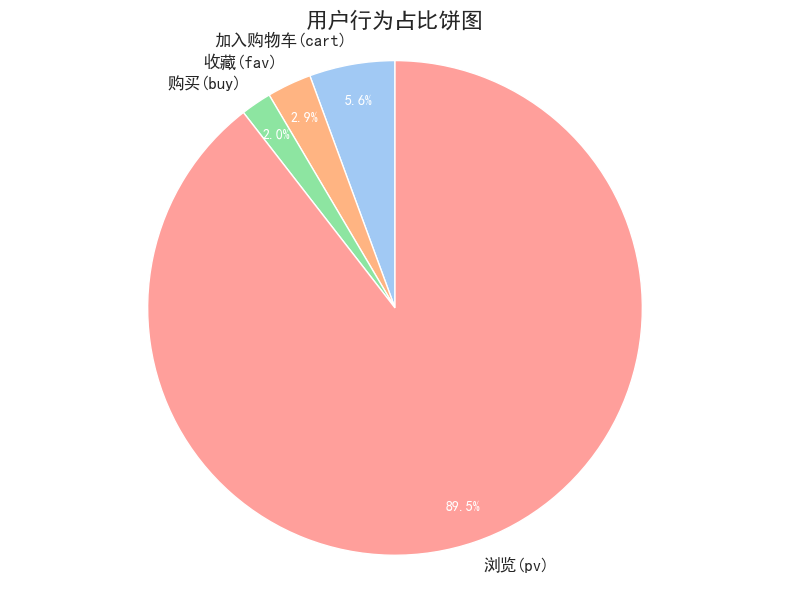

In [24]:
# 计算各行为总数量
total_buy = daily_buy.sum()
total_pv = daily_pv.sum()
total_cart = daily_cart.sum()
total_fav = daily_fav.sum()

# 确保中文显示正常
plt.rcParams['font.sans-serif'] = ['SimHei', 'WenQuanYi Micro Hei', 'Heiti TC', 'sans-serif']
plt.rcParams['axes.unicode_minus'] = False

# 准备饼图数据
behavior_data = [total_cart,total_fav, total_buy,total_pv]
behavior_labels = [ '加入购物车(cart)', '收藏(fav)', '购买(buy)','浏览(pv)']
behavior_colors = sns.color_palette('pastel')[0:4]

# 绘制饼图 - 解决文字重叠问题
plt.figure(figsize=(8, 6))  # 增大图表尺寸

# 绘制饼图，调整标签距离和百分比显示
wedges, texts, autotexts = plt.pie(
    behavior_data,
    labels=behavior_labels,
    colors=behavior_colors,
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops={'edgecolor': 'white'},
    labeldistance=1.1,  # 增加标签距离
    pctdistance=0.85,   # 调整百分比位置
    radius=0.8          # 调整饼图半径
)

# 调整文字大小和颜色
for text in texts:
    text.set_fontsize(12)
for autotext in autotexts:
    autotext.set_fontsize(10)
    autotext.set_color('white')

plt.title('用户行为占比饼图', fontsize=16)
plt.axis('equal')  # 确保饼图是圆形
plt.tight_layout()
plt.show()

饼图显示用户各行为占比情况

### (2).转化漏斗

=== 转化漏斗分析 ===
浏览用户数: 48782
收藏/加购用户数: 42631
购买用户数: 29848
pv → fav/cart 转化率: 87.39%
fav/cart → buy 转化率: 70.01%
购买用户占比61.19%


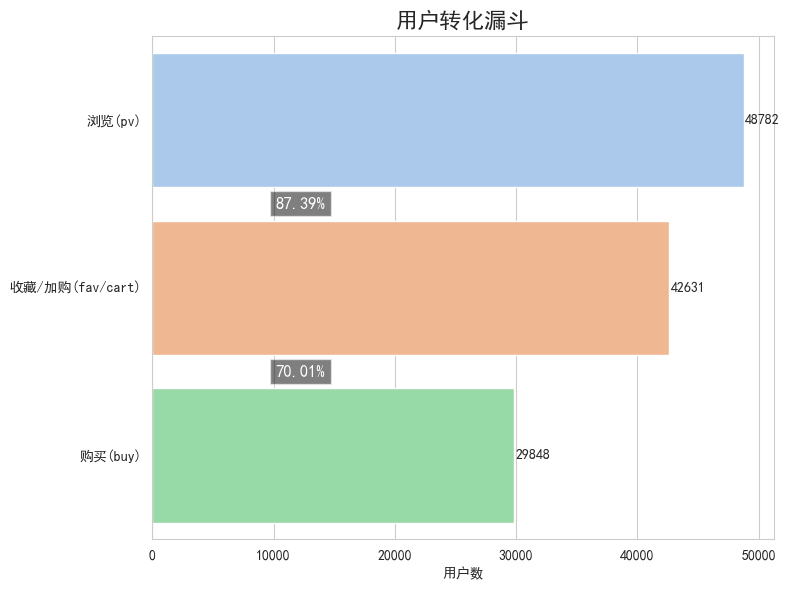

In [25]:
#统计各阶段用户数
# 浏览用户数
pv_users = df[df['behavior'] == 'pv']['user_id'].nunique()

#收藏/加购用户数
fav_cart_users = df[
    (df['behavior'].isin(['fav', 'cart'])) &
    (df['user_id'].isin(df[df['behavior'] == 'pv']['user_id']))
]['user_id'].nunique()

#购买用户数
buy_users = df[
    (df['behavior'] == 'buy') &
    (df['user_id'].isin(df[df['behavior'].isin(['fav', 'cart'])]['user_id'])) &
    (df['user_id'].isin(df[df['behavior'] == 'pv']['user_id']))
]['user_id'].nunique()

#计算转化率
pv_to_favcart_rate = (fav_cart_users / pv_users) * 100 if pv_users > 0 else 0
favcart_to_buy_rate = (buy_users / fav_cart_users) * 100 if fav_cart_users > 0 else 0

print("=== 转化漏斗分析 ===")
print(f"浏览用户数: {pv_users}")
print(f"收藏/加购用户数: {fav_cart_users}")
print(f"购买用户数: {buy_users}")
print(f"pv → fav/cart 转化率: {pv_to_favcart_rate:.2f}%")
print(f"fav/cart → buy 转化率: {favcart_to_buy_rate:.2f}%")
print(f"购买用户占比{(buy_users/pv_users * 100):.2f}%")

# 准备数据
funnel_data = [pv_users, fav_cart_users, buy_users]
funnel_labels = ['浏览(pv)', '收藏/加购(fav/cart)', '购买(buy)']

# 绘制漏斗图（使用水平条形图模拟）
plt.figure(figsize=(8, 6))
# 解决Seaborn警告
ax = sns.barplot(x=funnel_data, y=funnel_labels, hue=funnel_labels, palette='pastel', legend=False)

# 添加数值标签
for i, value in enumerate(funnel_data):
    plt.text(value + 100, i, f'{value}', va='center')

# 添加转化率标签 - 确保百分比对齐
align_x = max(funnel_data) * 0.25  # 统一在条形图的25%宽度位置

# 第一个转化率标签（pv到fav/cart）
plt.text(align_x, 0.5, f'{pv_to_favcart_rate:.2f}%',
         ha='center', va='center', color='white', fontsize=12,
         bbox=dict(facecolor='black', alpha=0.5))

# 第二个转化率标签（fav/cart到buy）
plt.text(align_x, 1.5, f'{favcart_to_buy_rate:.2f}%',
         ha='center', va='center', color='white', fontsize=12,
         bbox=dict(facecolor='black', alpha=0.5))

plt.title('用户转化漏斗', fontsize=16)
plt.xlabel('用户数')
plt.tight_layout()
plt.show()

### 分析

行为占比分析：

- 从用户行为占比饼图可以看出，浏览行为(pv)占比最高(89.5%)，购买行为(buy)仅占2.0%，加购物车(cart)和收藏(fav)分别占5.6%和2.9%。

用户转化漏斗分析：

- 浏览用户到收藏/加购的转化率为87.39%，说明大多数用户在浏览后对商品有兴趣

- 收藏/加购到购买的转化率为70.01%，表明有购买意向的用户中大部分最终完成了购买

- 最终购买用户占总浏览用户的61.19%，显示用户整体消费意愿较强


问题分析：

- 商品质量问题：部分商品可能存在质量不符合预期的情况，导致用户在收藏/加购后放弃购买

- 价格因素：价格可能是影响购买决策的重要因素，部分用户可能在最后阶段因价格考虑而放弃加购、收藏和购买

- 商品信息不完整：商品详情页信息可能不够全面，导致用户无法确认是否符合自己的需求

- 评论区影响：负面评论可能影响用户的购买信心

建议：

- 对高退货率商品进行重点监控和分析
- 针对收藏/加购用户推出个性化优惠
- 引导商家提供更全面的商品信息，包括详细参数、使用场景等

### (3).用户价值RFM分析

由于数据没有消费金额信息以及数据集时间间隔较小，只根据消费频率和最近消费时间进行用户价值分层。

In [26]:
groupby_buy_userid = df[df['behavior']=='buy'].groupby('user_id')

In [27]:
# 创建一个空的df，以groupby_buy_userid的userid列作为index，R、F作为列
RF = pd.DataFrame(index=groupby_buy_userid.groups.keys(), columns=['R', 'F'])

In [28]:
# 设置F为用户消费频率
RF['F'] = groupby_buy_userid['behavior'].count()

# 取出该用户最近一次消费时间#，以数据集的第二天（2017/12/04）进行分析，计算出距离上一次消费的间隔天数
RF['last_buy_time'] = groupby_buy_userid['time'].max()
RF['R'] = (pd.to_datetime('2017-12-04')-RF['last_buy_time']).dt.days
RF.sample(20)

,R,F,last_buy_time
2293,1,1,2017-12-02 21:13:20
149994,0,3,2017-12-03 15:11:30
198605,0,4,2017-12-03 19:03:38
14001,7,1,2017-11-26 13:11:52
149423,4,6,2017-11-29 15:19:10
1015578,0,4,2017-12-03 17:42:14
151794,0,2,2017-12-03 18:06:19
287037,3,3,2017-11-30 16:38:22
250775,0,1,2017-12-03 21:50:32
125653,0,1,2017-12-03 19:18:37


In [29]:
RF[["R","F"]].describe()

,R,F
count,33286.000000,33286.000000
mean,2.542691,3.008202
std,2.408730,2.974372
min,0.000000,1.000000
25%,0.000000,1.000000
50%,2.000000,2.000000
75%,4.000000,4.000000
max,8.000000,84.000000


最近的一次交易记录距离2017/12/04为0天，最远的为8天，平均为2.54天；交易次数最少为1次最多为84次,平均3次。（据此来制定打分标准）

In [30]:
def R_score(x):
    if 0 <= x < 1:
        return 4
    elif 1 <= x < 3:
        return 3
    elif 3 <= x < 5:
        return 2
    elif 5 <= x <= 8:
        return 1
    else:
        return 0

In [31]:
RF['R_score'] = RF['R'].apply(R_score)

In [32]:
def F_score(x):
    if 0 < x <= 1:
        return 1
    elif 1 < x <= 3:
        return 2
    elif 3 < x <= 5:
        return 3
    elif x > 5:
        return 4
    else:
        return 0

In [33]:
RF['F_score'] = RF['F'].apply(F_score)

In [34]:
# 新建两列，返回是否大于平均值，并转换成整数0、1
RF['R>mean?']=(RF['R_score']>RF['R_score'].mean())*1
RF['F>mean?']=(RF['F_score']>RF['F_score'].mean())*1

In [35]:
# 按照是否大于平均分评级
def Cus_level(tup):
    R_score, F_score = tup
    if R_score == 0 and F_score == 1:
        return "保持客户"
    elif R_score == 1 and F_score == 0:
        return "发展客户"
    elif R_score == 1 and F_score == 1:
        return "价值客户"
    elif R_score == 0 and F_score == 0:
        return "挽留客户"
    else:
        return None

In [36]:
RF['Cus_level'] = RF[['R>mean?', 'F>mean?']].apply(Cus_level, axis=1)

In [37]:
# 统计每个等级的用户数
leve_count = RF['Cus_level'].value_counts()
leve_count

Cus_level
挽留客户    12131
发展客户    12056
价值客户     7055
保持客户     2044
Name: count, dtype: int64

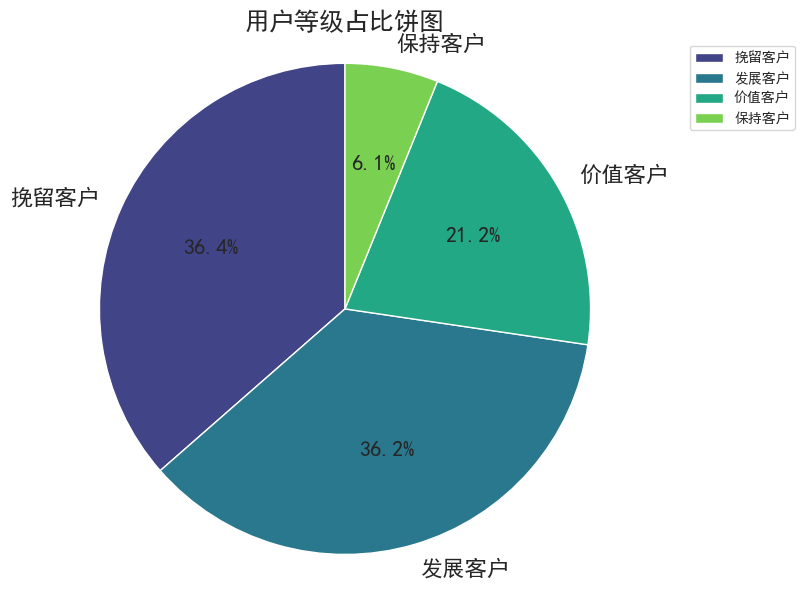

In [38]:
# 绘制饼图
plt.figure(figsize=(8, 6))

# 准备数据和标签
data = leve_count.values
labels = leve_count.index

# 设置颜色
colors = sns.color_palette('viridis', len(labels))

# 绘制饼图，添加百分比标签
plt.pie(
    data,
    labels=labels,
    colors=colors,
    autopct='%1.1f%%',  # 显示百分比，保留一位小数
    startangle=90,       # 起始角度
    wedgeprops={'edgecolor': 'white'},  # 设置饼图边缘颜色
    textprops={'fontsize': 16}          # 设置文本大小
)

# 添加标题
plt.title('用户等级占比饼图', fontsize=18)

# 确保饼图是圆形
plt.axis('equal')

# 显示图例
plt.legend(loc='upper right', bbox_to_anchor=(1.2, 1))

# 调整布局
plt.tight_layout()

# 显示图表
plt.show()

## 分析

问题分析（仅基于2017-11-25至2017-12-03数据）
- “价值客户”（21.2%）是当前的救命稻草：他们是这9天内持续活跃和购买的核心人群，是平台当下GMV的基石。
- “发展客户”占比高（36.2%）表明，很多用户在9天窗口的早期完成购买后，在短短几天内就进入了不活跃状态。这可能意味着促销后的留存很差，或用户体验存在即时痛点。
- “保持客户”占比极低（6.1%），这直接说明，在9天内，平台吸引新用户或激活老用户首次购买后，几乎无法促使他们产生第二次购买。用户增长漏斗在“首购”到“复购”这个关键环节严重断裂。

建议
- 重点维护价值客户，基于其历史偏好，推送关联高客单价商品或“会员专属套装”，提升客单价。
- 激发发展用户，他们是“新近购买但未复购”的用户。通过短信/Push推送其历史加购/收藏商品的降价信息或“专属归来券”。
- 提升保持客户，设置“二次购买有礼”任务，完成即赠优惠券，有效提升购买频率。
- 发展挽留客户，通过APP弹窗、公众号等低成本渠道，推送平台级爆款或“超高性价比”促销信息，测试其响应。

# 2.商品层面

商品类目有7354种，值得分析哪些品类的商品更受用户欢迎。


下面是已购买商品品类排名，未购买商品品类排名

In [39]:
cs = df[df['behavior']=='buy']['category_id'].value_counts().reset_index()
cs.columns = ['category_id', 'item_count']
cs

,category_id,item_count
0,1464116,1847
1,2735466,1797
2,4145813,1686
3,2885642,1582
4,4756105,1445
...,...,...
4050,3147601,1
4051,2573032,1
4052,3893658,1
4053,4670238,1


In [40]:
cs_nobuy = df[df['behavior']!='buy']['category_id'].value_counts().reset_index()
cs_nobuy.columns = ['category_id', 'item_count']
cs_nobuy

,category_id,item_count
0,4756105,263242
1,4145813,175984
2,2355072,168529
3,3607361,157019
4,982926,154121
...,...,...
7329,1961203,1
7330,5079277,1
7331,4788932,1
7332,475200,1


建议
- 重点推广已购买商品品类排行前列的品类，提升用户购买频率。
- 对未购买但进行浏览和加购收藏商品品类，需要分析其原因，是否是用户对商品的偏好问题，还是商品的属性问题。

# 3.场景层面

接下来将对用户行为进行场景分析，包括日周趋势图，24小时行为堆积图。

In [41]:
# 计算每日各行为数据
daily_behavior = df.groupby(['date', 'is_weekend', 'behavior']).size().unstack()
# 提取日期作为 x 轴
dates = [idx[0] for idx in daily_behavior.index]
daily_behavior

,behavior,buy,cart,fav,pv
date,is_weekend,,,,
2017-11-25,1,9890,28013,14876,461171
2017-11-26,1,10092,29544,15751,476245
2017-11-27,0,11088,27540,14551,446740
2017-11-28,0,10562,27109,14486,440340
2017-11-29,0,11145,27899,14893,456976
2017-11-30,0,11007,28225,14724,467215
2017-12-01,0,10509,31416,15477,486101
2017-12-02,1,12885,40253,20202,622231
2017-12-03,1,12953,39513,20165,615581


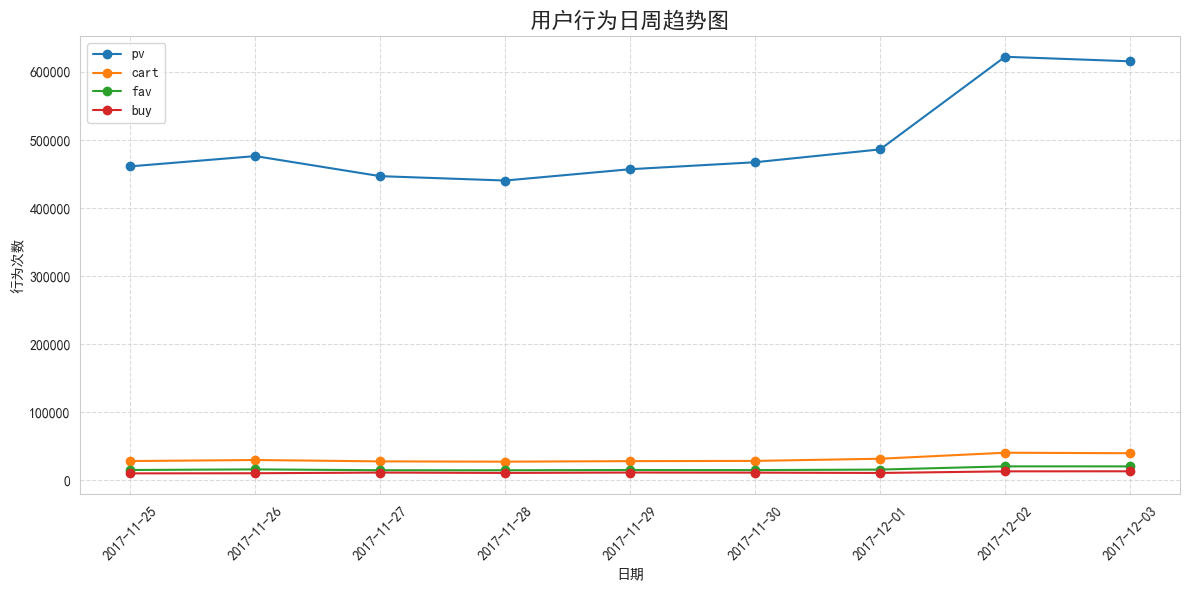

In [42]:

# 绘制日周趋势图
plt.figure(figsize=(12, 6))

for behavior in ['pv', 'cart', 'fav', 'buy']:
    plt.plot(dates, daily_behavior[behavior], marker='o', label=behavior)

plt.title('用户行为日周趋势图', fontsize=16)
plt.xlabel('日期')
plt.ylabel('行为次数')
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

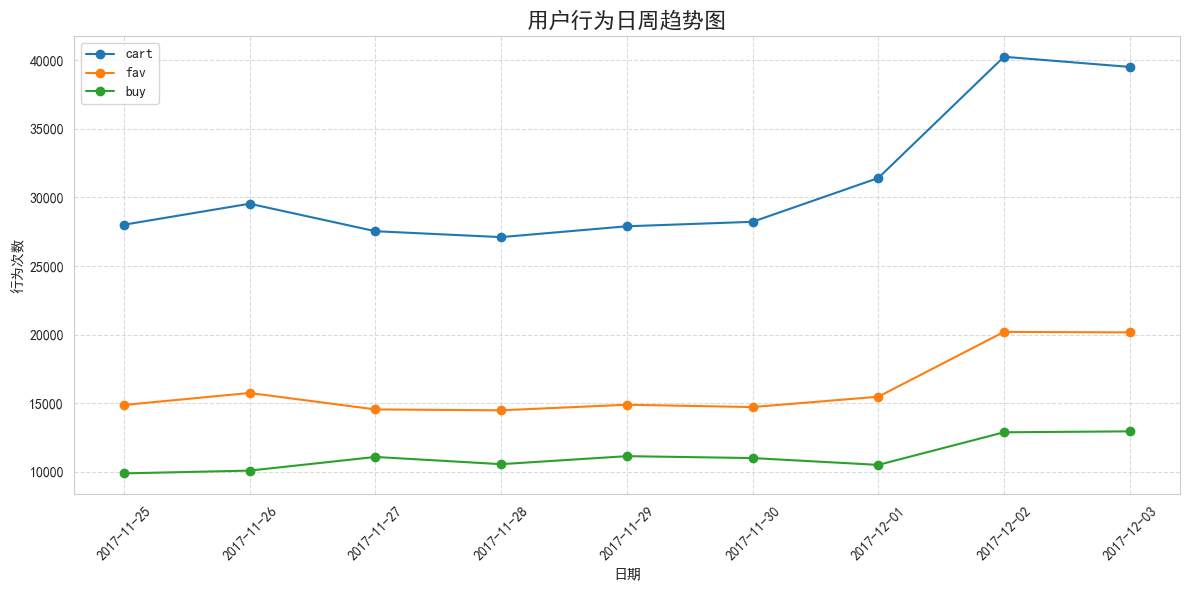

In [43]:
# 绘制日周趋势图(剔除浏览)
plt.figure(figsize=(12, 6))

for behavior in ['cart', 'fav', 'buy']:
    plt.plot(dates, daily_behavior[behavior], marker='o', label=behavior)

plt.title('用户行为日周趋势图', fontsize=16)
plt.xlabel('日期')
plt.ylabel('行为次数')
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

In [44]:
# 计算每小时各行为数据
hourly_behavior = df.groupby(['hour', 'behavior']).size().unstack()
hourly_behavior

behavior,buy,cart,fav,pv
hour,,,,
0,2916,9181,5070,149884
1,1101,4164,2295,68467
2,603,2150,1403,37536
3,302,1664,911,26422
4,328,1410,797,22544
5,380,1992,919,28039
6,922,3967,2169,60113
7,1845,7486,3843,111536
8,3186,9906,5409,154485


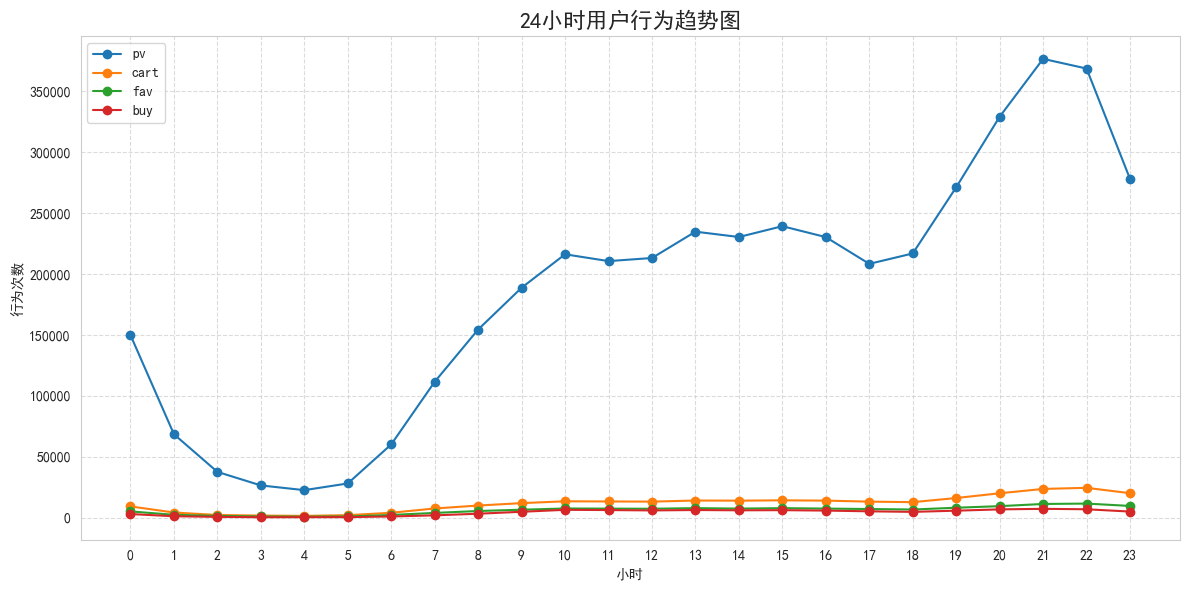

In [45]:
# 绘制24小时行为折线图
plt.figure(figsize=(12, 6))

for behavior in ['pv', 'cart', 'fav', 'buy']:
    plt.plot(hourly_behavior.index, hourly_behavior[behavior], marker='o', label=behavior)

plt.title('24小时用户行为趋势图', fontsize=16)
plt.xlabel('小时')
plt.ylabel('行为次数')
plt.xticks(range(0, 24))
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

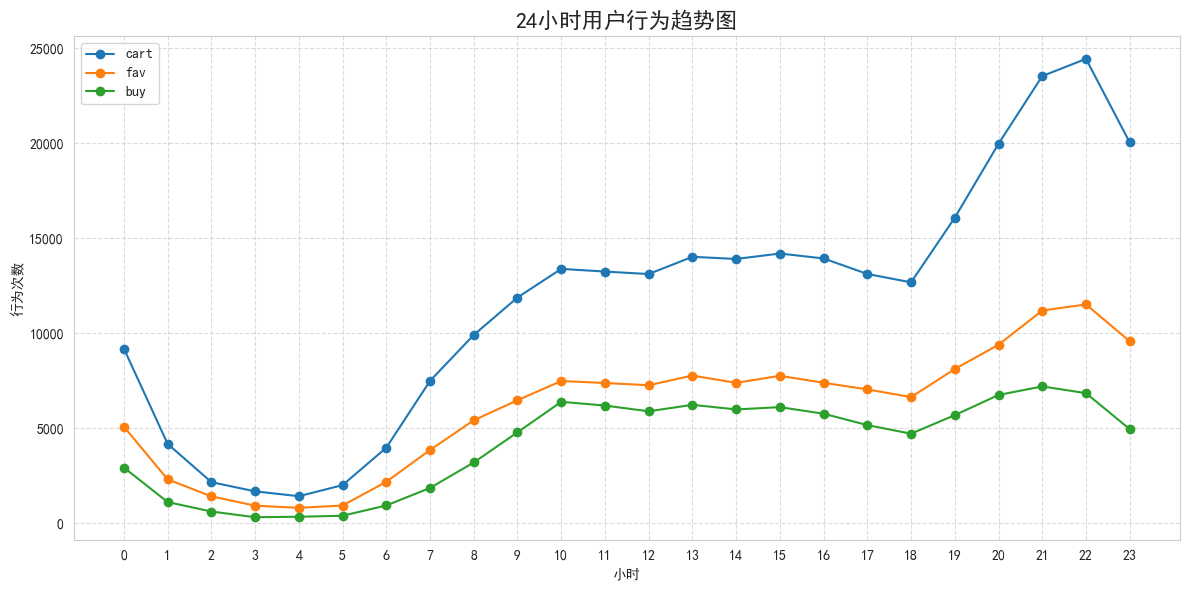

In [46]:
# 绘制24小时行为折线图
plt.figure(figsize=(12, 6))

for behavior in ['cart', 'fav', 'buy']:
    plt.plot(hourly_behavior.index, hourly_behavior[behavior], marker='o', label=behavior)

plt.title('24小时用户行为趋势图', fontsize=16)
plt.xlabel('小时')
plt.ylabel('行为次数')
plt.xticks(range(0, 24))
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

# 分析

根据用户行为日周趋势图，可以看到：
- 周末用户行为量大于平日，说明用户在周末更愿意进行购物。
- 而11月25、26日比12月01、02日用户行为量小，说明月初用户更愿意进行购物。

根据24小时用户行为趋势图，可以看到：

1. 用户活跃的"双峰"与"单峰"模式

- 凌晨小高峰（0-1点）：图1显示cart在凌晨有接近1万次的小高峰

  解读：可能是"睡前经济"或跨日促销活动的体现

  用户画像：夜猫子用户群体，决策相对冲动

- 晚间主高峰（21-22点）：所有行为在此时段达到峰值

  cart峰值：24k+

  pv峰值：350k+

  解读：下班后的"黄金购物时段"，用户有充足时间浏览决策

  业务意义：这是全天最重要的营销和运营窗口

2. 低谷时段的机遇分析

- 凌晨低谷（4-6点）：所有行为均处于最低水平

  传统认知：这是无效时段

  创新视角：可能是跨境购物的黄金窗口（时区差异），或是设置"晨间专属优惠"的蓝海时段

  日间平稳期（10-18点）：buy行为保持稳定

  解读：可能是办公时段的"碎片化购物"，适合推送高决策效率的标准品